
✔️ Saved final predictions to 'mock_predictions.csv'

--- Evaluation Metrics ---
Accuracy: 1.0000
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        16
     Malware       1.00      1.00      1.00         8

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24

Confusion Matrix:
 [[16  0]
 [ 0  8]]

Top 3 Important Features:
Entropy: 1.0000
Size: 0.0000
Entropy_StdDev: 0.0000


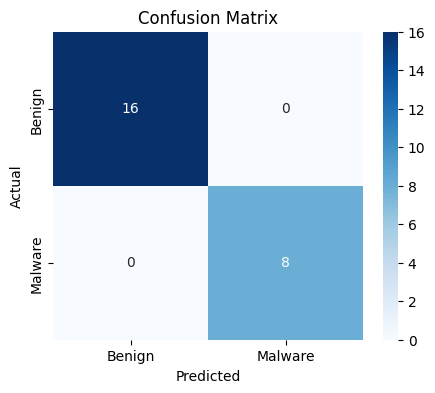


Model saved as 'mock_malware_dt_model.joblib'


In [1]:
# Step 2: Import libraries
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from joblib import dump
import matplotlib.pyplot as plt
import seaborn as sns

# Step 3: Generate mock dataset
def generate_mock_data(n_samples=120):
    np.random.seed(42)
    data = []
    for i in range(n_samples):
        is_malware = 1 if i < n_samples // 2 else 0  # First half: malware, second half: benign
        size = np.random.randint(100_000, 5_000_000) if is_malware else np.random.randint(100_000, 3_000_000)
        entropy = np.random.uniform(6.5, 8.0) if is_malware else np.random.uniform(4.5, 6.5)
        entropy_std = np.random.uniform(0.8, 1.5) if is_malware else np.random.uniform(0.2, 0.9)
        rare_imports = np.random.randint(1, 6) if is_malware else np.random.randint(0, 2)

        data.append({
            "Filename": f"file_{i}.exe",
            "Size": size,
            "Entropy": round(entropy, 3),
            "Entropy_StdDev": round(entropy_std, 3),
            "Rare_Imports_Count": rare_imports,
            "Label": is_malware
        })
    return pd.DataFrame(data)

# Step 4: Load mock data
df = generate_mock_data()
df.to_csv("mock_features.csv", index=False)

# Step 5: Prepare features and labels
X = df[["Size", "Entropy", "Entropy_StdDev", "Rare_Imports_Count"]]
y = df["Label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Step 6: Train Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=5, random_state=1)
clf.fit(X_train, y_train)

# Step 7: Predict and evaluate
# Step 7: Predict and save final CSV as specified
y_pred = clf.predict(X_test)
df.loc[X_test.index, "Predicted_Label"] = y_pred

# Save only required columns to CSV
output_df = df.loc[X_test.index, ["Filename", "Size", "Entropy", "Entropy_StdDev", "Rare_Imports_Count", "Predicted_Label"]]
output_df.to_csv("mock_predictions.csv", index=False)
print("\n✔️ Saved final predictions to 'mock_predictions.csv'")


print("\n--- Evaluation Metrics ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malware"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 8: Feature importance
importances = clf.feature_importances_
features = X.columns
important_features = sorted(zip(features, importances), key=lambda x: x[1], reverse=True)

print("\nTop 3 Important Features:")
for name, score in important_features[:3]:
    print(f"{name}: {score:.4f}")

# Step 9: Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Benign", "Malware"], yticklabels=["Benign", "Malware"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Step 10: Save the model
dump(clf, "mock_malware_dt_model.joblib")
print("\nModel saved as 'mock_malware_dt_model.joblib'")
